# Product Name TF-IDF by Period Window (상의)

상의 카테고리만 대상으로, 기간 윈도우별(월-주-일-실시간) TF-IDF 기반 스타일 단어를 검증합니다.

In [1]:
# 필요시 1회 설치
# %pip install scikit-learn pandas matplotlib wordcloud

from __future__ import annotations

import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import wordcloud_lab as wl

In [2]:
RUNS_DIR = PROJECT_ROOT / "runs"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "product_name_period_window_tfidf"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_DIR: Path | None = None
TARGET_CATEGORY_CODE = "001000"  # 상의
TARGET_CATEGORY_LABEL = "상의"
WINDOW_ORDER = ("1m", "1w", "1d", "rt")  # 월-주-일-실시간
WINDOW_LABEL_KR = {"1m": "월간", "1w": "주간", "1d": "일간", "rt": "실시간"}

# 카테고리 내부 TF-IDF 하이퍼파라미터
TOP_K = 40
NGRAM_RANGE = (1, 2)
MIN_PRODUCTS_PER_WINDOW = 30
MIN_DF_RATIO = 0.005
MAX_DF_RATIO = 0.35
USE_SUBLINEAR_TF = True

run_dir = wl.resolve_run_dir(RUNS_DIR, RUN_DIR)
items = wl.load_items(run_dir)
product_only = wl.product_items(items)

font_path, _ = wl.init_fonts()
if font_path:
    print(f"font: {font_path}")
print(f"run_dir={run_dir}")
print(f"items={len(items):,}, product_only={len(product_only):,}")

font: /System/Library/Fonts/Supplemental/AppleGothic.ttf
run_dir=/Users/bhc/dev/datadrift/v1/datadrift_app_engine/v2/silhouette_outliner/runs/20260527_172433
items=13,747, product_only=12,000


In [3]:
def build_window_product_docs(items: list[dict]) -> pd.DataFrame:
    """상의 카테고리에서 상품 1개=문서로, 윈도우별 문서 집합을 만든다."""
    ubiquitous = wl.ubiquitous_for_items(items)
    rows: list[dict] = []

    for it in wl.product_items(items):
        code, label = wl.category_key(it)
        if code != TARGET_CATEGORY_CODE and label != TARGET_CATEGORY_LABEL:
            continue
        wid, wlabel = wl.window_key(it)
        if wid not in WINDOW_ORDER:
            continue

        name = wl.product_display_name(it)
        if not name:
            continue

        stop = wl.generic_stopwords_for(code, label, ubiquitous)
        toks = [t for t in wl.tokenize_product_name(name) if t not in stop]
        if not toks:
            continue

        rows.append(
            {
                "category_code": code,
                "category_label": label,
                "window_id": wid,
                "window_label": wlabel or WINDOW_LABEL_KR.get(wid, wid),
                "tokens": toks,
                "doc": " ".join(toks),
            }
        )

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    order_map = {wid: i for i, wid in enumerate(WINDOW_ORDER)}
    df["_w_order"] = df["window_id"].map(order_map).fillna(999).astype(int)
    return df.sort_values(["_w_order", "window_id"]).drop(columns=["_w_order"]).reset_index(drop=True)


window_docs_df = build_window_product_docs(items)
if window_docs_df.empty:
    raise ValueError("상의 카테고리 문서가 비어 있습니다. 코드/라벨 또는 입력 데이터를 확인하세요.")

window_stats_df = (
    window_docs_df.groupby(["window_id", "window_label"], as_index=False)
    .agg(product_docs=("doc", "count"), token_count=("tokens", lambda s: int(sum(len(x) for x in s))))
)
window_stats_df["_w_order"] = window_stats_df["window_id"].map({wid: i for i, wid in enumerate(WINDOW_ORDER)})
window_stats_df.sort_values("_w_order").drop(columns=["_w_order"])

,window_id,window_label,product_docs,token_count
1,1m,월간,96,301
2,1w,주간,2039,6797
0,1d,일간,93,313
3,rt,실시간,677,2318


In [4]:
def run_tfidf_per_window(window_docs_df: pd.DataFrame) -> pd.DataFrame:
    records: list[dict] = []
    for wid in WINDOW_ORDER:
        group = window_docs_df[window_docs_df["window_id"] == wid].copy()
        if group.empty:
            continue

        n_docs = len(group)
        if n_docs < MIN_PRODUCTS_PER_WINDOW:
            continue

        min_df = max(1, int(np.ceil(n_docs * MIN_DF_RATIO)))
        vectorizer = TfidfVectorizer(
            tokenizer=str.split,
            preprocessor=None,
            token_pattern=None,
            lowercase=False,
            ngram_range=NGRAM_RANGE,
            min_df=min_df,
            max_df=MAX_DF_RATIO,
            sublinear_tf=USE_SUBLINEAR_TF,
        )
        X = vectorizer.fit_transform(group["doc"].tolist())
        terms = np.array(vectorizer.get_feature_names_out())
        tfidf_sum = np.asarray(X.sum(axis=0)).ravel()
        df_ratio = np.asarray((X > 0).sum(axis=0)).ravel() / n_docs

        order = np.argsort(tfidf_sum)[::-1][:TOP_K]
        for rank, j in enumerate(order, start=1):
            records.append(
                {
                    "window_id": wid,
                    "window_label": WINDOW_LABEL_KR.get(wid, wid),
                    "n_docs": n_docs,
                    "rank": rank,
                    "term": terms[j],
                    "tfidf": float(tfidf_sum[j]),
                    "doc_freq_ratio": float(df_ratio[j]),
                }
            )

    return pd.DataFrame(records)


top_terms_df = run_tfidf_per_window(window_docs_df)
if top_terms_df.empty:
    raise ValueError("윈도우별 TF-IDF 결과가 비었습니다. MIN_PRODUCTS_PER_WINDOW / MAX_DF_RATIO 등을 조정하세요.")
top_terms_df.head(30)

,window_id,window_label,n_docs,rank,term,tfidf,doc_freq_ratio
0,1m,월간,96,1,반팔,7.178189,0.333333
1,1m,월간,96,2,헨리넥,3.416826,0.125000
2,1m,월간,96,3,tag,3.061715,0.041667
3,1m,월간,96,4,폴로,2.839021,0.083333
4,1m,월간,96,5,니트,2.690001,0.093750
5,1m,월간,96,6,와플,2.488221,0.062500
6,1m,월간,96,7,크루,2.313695,0.052083
7,1m,월간,96,8,롤업,2.244562,0.072917
8,1m,월간,96,9,반팔티,2.186780,0.062500
9,1m,월간,96,10,스트라이프,2.181109,0.041667


## 워드클라우드 (월-주-일-실시간)

각 윈도우에서 TF-IDF 상위 용어만 남기고, 글자 크기는 해당 윈도우의 원본 토큰 빈도로 표시합니다.

In [5]:
def count_term_in_tokens(term: str, tokens: list[str]) -> int:
    parts = term.split()
    n = len(parts)
    if n == 1:
        return tokens.count(term)
    return sum(1 for i in range(len(tokens) - n + 1) if tokens[i : i + n] == parts)


def count_term_in_docs(term: str, docs_tokens: list[list[str]]) -> int:
    return sum(count_term_in_tokens(term, toks) for toks in docs_tokens)


def counter_from_terms(terms: list[str], docs_tokens: list[list[str]]) -> Counter:
    ctr: Counter = Counter()
    for term in terms:
        c = count_term_in_docs(term, docs_tokens)
        if c > 0:
            ctr[term] = c
    return ctr


raw_by_window: dict[str, Counter] = {}
for wid in WINDOW_ORDER:
    docs_tokens = window_docs_df.loc[window_docs_df["window_id"] == wid, "tokens"].tolist()
    if docs_tokens:
        raw_by_window[wid] = Counter(tok for toks in docs_tokens for tok in toks)

filtered_by_window: dict[str, Counter] = {}
freq_rows: list[dict] = []
for wid in WINDOW_ORDER:
    group = top_terms_df[top_terms_df["window_id"] == wid]
    if group.empty:
        continue
    docs_tokens = window_docs_df.loc[window_docs_df["window_id"] == wid, "tokens"].tolist()
    ctr = counter_from_terms(group["term"].tolist(), docs_tokens)
    filtered_by_window[wid] = ctr
    for _, row in group.iterrows():
        freq_rows.append({**row.to_dict(), "count": ctr.get(row["term"], 0)})

top_terms_with_freq = pd.DataFrame(freq_rows)
top_terms_with_freq.head(20)

,window_id,window_label,n_docs,rank,term,tfidf,doc_freq_ratio,count
0,1m,월간,96,1,반팔,7.178189,0.333333,32
1,1m,월간,96,2,헨리넥,3.416826,0.125000,12
2,1m,월간,96,3,tag,3.061715,0.041667,4
3,1m,월간,96,4,폴로,2.839021,0.083333,8
4,1m,월간,96,5,니트,2.690001,0.093750,9
5,1m,월간,96,6,와플,2.488221,0.062500,6
6,1m,월간,96,7,크루,2.313695,0.052083,5
7,1m,월간,96,8,롤업,2.244562,0.072917,7
8,1m,월간,96,9,반팔티,2.186780,0.062500,6
9,1m,월간,96,10,스트라이프,2.181109,0.041667,4


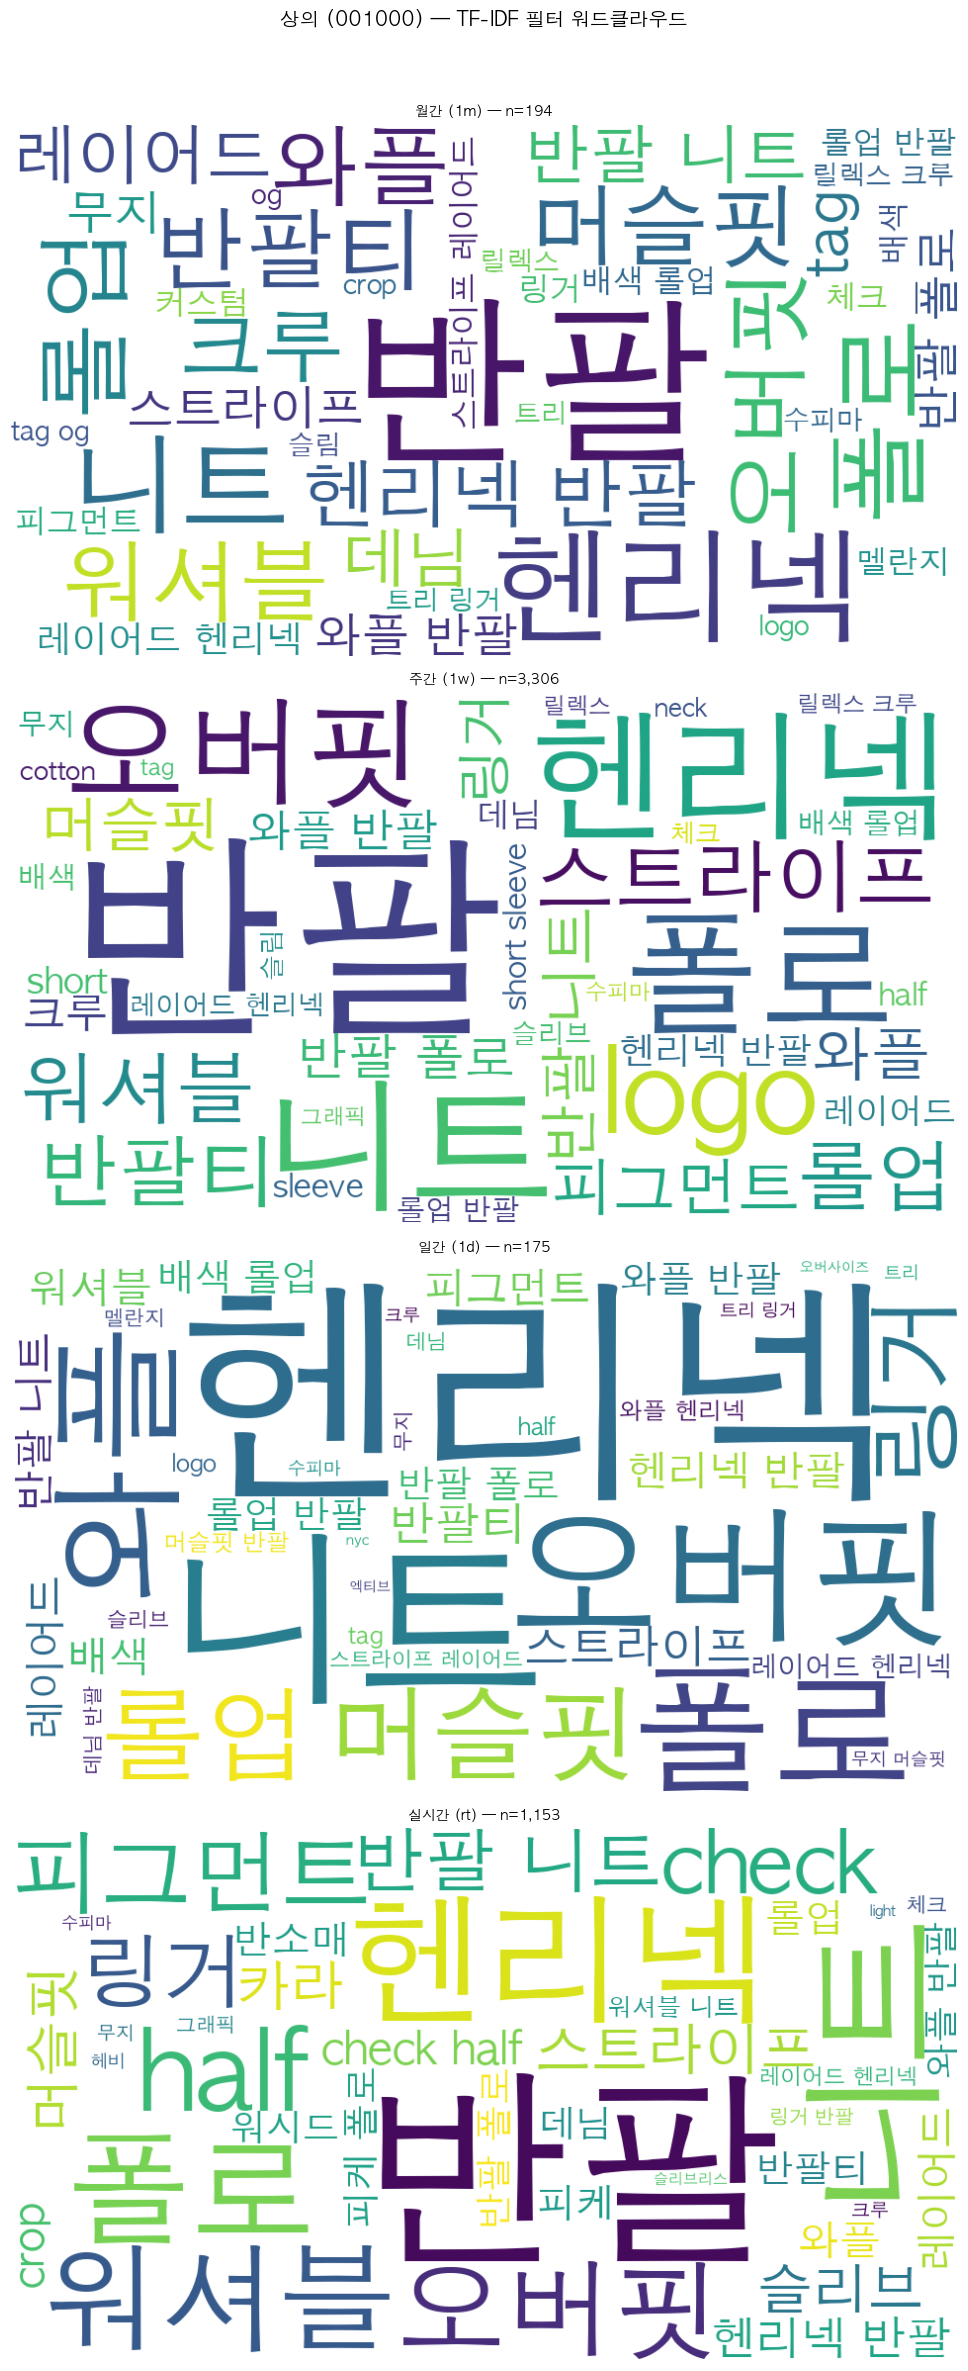

In [6]:
panels: list[tuple[str, Counter]] = []
for wid in WINDOW_ORDER:
    if wid not in filtered_by_window:
        continue
    subtitle = f"{WINDOW_LABEL_KR.get(wid, wid)} ({wid})"
    panels.append((subtitle, filtered_by_window[wid]))

wl.plot_wordcloud_grid(
    panels,
    suptitle=f"상의 ({TARGET_CATEGORY_CODE}) — TF-IDF 필터 워드클라우드",
    ncols=1,
    figsize_per_cell=(12.0, 5.8),
    save_path=OUTPUT_DIR / f"{run_dir.name}_{TARGET_CATEGORY_CODE}_period_window_tfidf_wordcloud.png",
)

In [7]:
for wid in WINDOW_ORDER:
    group = top_terms_with_freq[top_terms_with_freq["window_id"] == wid]
    if group.empty:
        continue
    print(f"\n=== {WINDOW_LABEL_KR.get(wid, wid)} ({wid}) ===")
    display(group[["rank", "term", "count", "doc_freq_ratio", "tfidf"]].sort_values("rank").head(TOP_K))


=== 월간 (1m) ===


,rank,term,count,doc_freq_ratio,tfidf
0,1,반팔,32,0.333333,7.178189
1,2,헨리넥,12,0.125000,3.416826
2,3,tag,4,0.041667,3.061715
3,4,폴로,8,0.083333,2.839021
4,5,니트,9,0.093750,2.690001
5,6,와플,6,0.062500,2.488221
6,7,크루,5,0.052083,2.313695
7,8,롤업,7,0.072917,2.244562
8,9,반팔티,6,0.062500,2.186780
9,10,스트라이프,4,0.041667,2.181109



=== 주간 (1w) ===


,rank,term,count,doc_freq_ratio,tfidf
40,1,반팔,538,0.263855,139.077914
41,2,logo,106,0.051986,75.472844
42,3,니트,174,0.085336,54.550068
43,4,폴로,149,0.073075,53.819323
44,5,헨리넥,165,0.080922,51.677804
45,6,스트라이프,106,0.051986,50.966051
46,7,피그먼트,94,0.045120,46.709525
47,8,반팔티,104,0.051005,42.713481
48,9,오버핏,117,0.057381,41.005079
49,10,롤업,100,0.049044,38.326017



=== 일간 (1d) ===


,rank,term,count,doc_freq_ratio,tfidf
80,1,헨리넥,16,0.172043,4.593636
81,2,와플,7,0.075269,3.131583
82,3,폴로,7,0.075269,2.647568
83,4,니트,9,0.096774,2.615400
84,5,머슬핏,7,0.075269,2.522073
85,6,tag,3,0.032258,2.518297
86,7,logo,3,0.032258,2.518297
87,8,링거,6,0.064516,2.320495
88,9,롤업,7,0.075269,2.286839
89,10,스트라이프,6,0.064516,2.045257



=== 실시간 (rt) ===


,rank,term,count,doc_freq_ratio,tfidf
120,1,반팔,196,0.289513,55.987855
121,2,헨리넥,73,0.107829,27.389016
122,3,니트,81,0.119645,25.282829
123,4,폴로,55,0.081241,24.334820
124,5,half,41,0.060561,22.814063
125,6,워셔블,50,0.073855,15.952774
126,7,오버핏,41,0.060561,15.660603
127,8,피그먼트,35,0.051699,14.889850
128,9,링거,29,0.042836,14.215396
129,10,check,30,0.044313,12.439659


In [8]:
summary_df = (
    top_terms_with_freq.groupby(["window_id", "window_label"], as_index=False)
    .agg(
        top_term_count=("term", "count"),
        product_docs=("n_docs", "max"),
        max_tfidf=("tfidf", "max"),
        mean_tfidf=("tfidf", "mean"),
        mean_doc_freq_ratio=("doc_freq_ratio", "mean"),
    )
)
summary_df["_w_order"] = summary_df["window_id"].map({wid: i for i, wid in enumerate(WINDOW_ORDER)})
summary_df.sort_values("_w_order").drop(columns=["_w_order"])

,window_id,window_label,top_term_count,product_docs,max_tfidf,mean_tfidf,mean_doc_freq_ratio
1,1m,월간,40,96,7.178189,1.870565,0.050521
2,1w,주간,40,2039,139.077914,34.537834,0.040510
0,1d,일간,40,93,4.593636,1.795585,0.047043
3,rt,실시간,40,677,55.987855,12.052477,0.042578


In [9]:
run_name = run_dir.name
out_top = OUTPUT_DIR / f"{run_name}_{TARGET_CATEGORY_CODE}_period_window_tfidf_top_terms.csv"
out_freq = OUTPUT_DIR / f"{run_name}_{TARGET_CATEGORY_CODE}_period_window_tfidf_top_terms_with_freq.csv"
out_summary = OUTPUT_DIR / f"{run_name}_{TARGET_CATEGORY_CODE}_period_window_tfidf_summary.csv"

top_terms_df.to_csv(out_top, index=False, encoding="utf-8-sig")
top_terms_with_freq.to_csv(out_freq, index=False, encoding="utf-8-sig")
summary_df.drop(columns=["_w_order"], errors="ignore").to_csv(out_summary, index=False, encoding="utf-8-sig")

print("saved:", out_top)
print("saved:", out_freq)
print("saved:", out_summary)

saved: /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v2/silhouette_outliner/notebooks/output/product_name_period_window_tfidf/20260527_172433_001000_period_window_tfidf_top_terms.csv
saved: /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v2/silhouette_outliner/notebooks/output/product_name_period_window_tfidf/20260527_172433_001000_period_window_tfidf_top_terms_with_freq.csv
saved: /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v2/silhouette_outliner/notebooks/output/product_name_period_window_tfidf/20260527_172433_001000_period_window_tfidf_summary.csv
